# 04 — Clustering Data-Driven Final V3

Notebook ini melakukan pemodelan K-Means terhadap dataset hasil NLP final.

## Input resmi

`03_Data_Modeling_Setelah_NLP.csv`

## Fitur utama K-Means

1. `totalScore`
2. `log_reviewsCount = log1p(reviewsCount)`
3. `sentiment_score`

Kolom identitas, teks, kategori, dan tingkat kecukupan ulasan dipertahankan untuk interpretasi, tetapi **tidak dimasukkan ke perhitungan jarak K-Means**.

## Penanganan keterbatasan sentiment analysis

Beberapa hasil NLP dapat tidak sesuai dengan makna manusia, terutama pada bahasa daerah, slang, ejaan tidak baku, ulasan sangat pendek, dan konteks lokal.

Versi sebelumnya menggunakan pencarian kata seperti `order`, `WhatsApp`, dan nomor kontak untuk menandai kemungkinan promosi. Aturan tersebut terlalu luas dan menghasilkan false positive pada ulasan pelanggan yang normal. Karena itu, versi ini tidak lagi menganggap penyebutan pemesanan, WhatsApp, admin, transfer, atau kontak sebagai masalah.

Audit NLP pada versi ini hanya menandai kasus yang lebih konservatif:

1. rating tinggi tetapi hasil sentimen netral/negatif;
2. sentimen netral/negatif yang hanya berdasarkan satu atau dua teks;
3. teks yang secara eksplisit memuat penanda `(Pemilik)`.

Flag hanya digunakan sebagai daftar pemeriksaan internal. Flag tidak mengubah label sentimen, tidak menghapus data, tidak menjadi fitur K-Means, dan tidak boleh diperlakukan sebagai bukti bahwa ulasan bermasalah.

## Batas interpretasi `reviewsCount`

Jumlah ulasan Google Maps tidak sama dengan jumlah pelanggan, kunjungan, transaksi, penjualan, atau tingkat keramaian offline. Cluster dengan volume ulasan rendah hanya boleh dijelaskan sebagai kelompok dengan jejak ulasan digital yang relatif lebih terbatas.


In [ ]:

# ============================================================
# 1. INSTALASI LIBRARY
# ============================================================
!pip install -q kneed openpyxl


In [ ]:

# ============================================================
# 2. IMPORT LIBRARY
# ============================================================
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.preprocessing import MinMaxScaler

try:
    from google.colab import files
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 180)

print("Library berhasil dimuat.")


Library berhasil dimuat.


In [ ]:

# ============================================================
# 3. KONFIGURASI
# ============================================================
INPUT_FILE = "03_Data_Modeling_Setelah_NLP.csv"

OUTPUT_CLUSTER_CSV = "04_Hasil_Clustering_Final.csv"
OUTPUT_MODELING_CSV = "04_Data_Modeling_Ringkas.csv"
OUTPUT_AUDIT_CSV = "04_Hasil_Clustering_dan_Audit.csv"

FINAL_K = 3
RANDOM_STATE = 42
N_INIT = 10
K_MIN = 1
K_MAX = 10

FEATURES_MAIN = [
    "totalScore",
    "log_reviewsCount",
    "sentiment_score",
]

FEATURES_SENSITIVITY = [
    "totalScore",
    "log_reviewsCount",
]

EXPECTED_ROWS = 3438

print("Konfigurasi selesai.")


Konfigurasi selesai.


In [ ]:

# ============================================================
# 4. UPLOAD INPUT
# ============================================================
if not os.path.exists(INPUT_FILE):
    if not RUNNING_IN_COLAB:
        raise FileNotFoundError(INPUT_FILE)

    print("Upload file:", INPUT_FILE)
    uploaded = files.upload()

    if INPUT_FILE not in uploaded:
        csv_files = [
            name for name in uploaded
            if name.lower().endswith(".csv")
        ]

        if len(csv_files) != 1:
            raise FileNotFoundError(
                "Upload tepat satu file CSV hasil NLP."
            )

        os.rename(csv_files[0], INPUT_FILE)

print("File input ditemukan:", INPUT_FILE)


File input ditemukan: 03_Data_Modeling_Setelah_NLP.csv


In [ ]:

# ============================================================
# 5. MEMBACA DAN MEMVALIDASI DATA
# ============================================================
df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
    on_bad_lines="warn",
)

required_columns = [
    "entity_key",
    "title",
    "totalScore",
    "reviewsCount",
    "street",
    "city",
    "categoryName",
    "text",
    "jumlah_teks_untuk_sentimen",
    "sentiment_score",
    "sentimen_confidence",
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Kolom wajib tidak tersedia: {missing_columns}"
    )

df = df[required_columns].copy()

df["totalScore"] = pd.to_numeric(
    df["totalScore"]
    .astype(str)
    .str.replace(",", ".", regex=False),
    errors="coerce",
)

df["reviewsCount"] = pd.to_numeric(
    df["reviewsCount"],
    errors="coerce",
)

df["jumlah_teks_untuk_sentimen"] = pd.to_numeric(
    df["jumlah_teks_untuk_sentimen"],
    errors="coerce",
).astype("Int64")

df["sentiment_score"] = pd.to_numeric(
    df["sentiment_score"],
    errors="coerce",
).astype("Int64")

assert len(df) == EXPECTED_ROWS, (
    f"Jumlah data bukan {EXPECTED_ROWS}: {len(df)}"
)

assert df["entity_key"].notna().all()
assert df["entity_key"].is_unique
assert df["title"].notna().all()
assert df["totalScore"].between(
    1, 5, inclusive="both"
).all()
assert (df["reviewsCount"] >= 1).all()
assert df["sentiment_score"].isin(
    [-1, 0, 1]
).all()

print("Jumlah data:", len(df))
print("Jumlah kolom:", df.shape[1])

print("\nDistribusi sentiment_score:")
display(
    df["sentiment_score"]
    .value_counts()
    .sort_index()
    .rename("jumlah")
    .to_frame()
)

print("\nDistribusi tingkat kecukupan:")
display(
    df["sentimen_confidence"]
    .value_counts()
    .rename("jumlah")
    .to_frame()
)


Jumlah data: 3438
Jumlah kolom: 11

Distribusi sentiment_score:


,jumlah
sentiment_score,
-1,422
0,86
1,2930



Distribusi tingkat kecukupan:


,jumlah
sentimen_confidence,
Tinggi,2846
Sedang,297
Rendah,295



## Mengapa label NLP yang tampak salah tidak langsung diubah?

Contoh seperti bahasa Sunda yang bermakna positif tetapi diprediksi negatif menunjukkan keterbatasan model, bukan bukti bahwa seluruh proses gagal.

Perubahan manual hanya layak dilakukan apabila tersedia:

- panduan anotasi;
- minimal dua penilai;
- sampel berlabel;
- aturan penyelesaian perbedaan;
- evaluasi akurasi, precision, recall, dan F1-score.

Karena data berlabel manual belum tersedia, notebook mempertahankan output model dan menandai kasus yang perlu kehati-hatian.


In [ ]:
# ============================================================
# 6. AUDIT NLP KONSERVATIF
# ============================================================
text_lower = (
    df["text"]
    .fillna("")
    .astype(str)
    .str.lower()
)

# Konflik antara rating listing yang sangat tinggi dan hasil NLP nonpositif.
# Ini hanya kandidat pemeriksaan, bukan bukti bahwa model pasti salah.
df["flag_rating_sentiment_conflict"] = (
    (df["totalScore"] >= 4.5)
    & (df["sentiment_score"] <= 0)
)

# Sentimen nonpositif dengan hanya 1-2 teks lebih rentan terhadap bias sampel.
# Data positif dengan 1-2 teks tidak otomatis diberi flag.
df["flag_low_coverage_nonpositive"] = (
    df["sentimen_confidence"]
    .astype(str)
    .isin(["Rendah", "Sedang"])
    & (df["sentiment_score"] <= 0)
)

# Hanya penanda eksplisit dari Google Maps yang digunakan.
# Kata "order", "WhatsApp", "admin", "transfer", dan nomor kontak
# tidak lagi dijadikan alasan flag karena sering muncul dalam ulasan normal.
explicit_owner_pattern = r"\(\s*pemilik\s*\)"

df["flag_explicit_owner_marker"] = (
    text_lower.str.contains(
        explicit_owner_pattern,
        regex=True,
        na=False,
    )
)

df["nlp_review_flag"] = (
    df[
        [
            "flag_rating_sentiment_conflict",
            "flag_low_coverage_nonpositive",
            "flag_explicit_owner_marker",
        ]
    ]
    .any(axis=1)
)

def build_nlp_review_reason(row):
    reasons = []

    if row["flag_rating_sentiment_conflict"]:
        reasons.append(
            "Rating listing tinggi tetapi hasil NLP netral/negatif"
        )

    if row["flag_low_coverage_nonpositive"]:
        reasons.append(
            "Hasil NLP nonpositif hanya berdasarkan 1-2 teks"
        )

    if row["flag_explicit_owner_marker"]:
        reasons.append(
            "Teks memuat penanda eksplisit (Pemilik)"
        )

    return " | ".join(reasons)

df["nlp_review_reason"] = df.apply(
    build_nlp_review_reason,
    axis=1,
)

audit_sentiment = df[
    df["nlp_review_flag"]
].copy()

audit_summary = pd.DataFrame([
    {
        "indikator": "Rating >= 4.5 tetapi hasil NLP <= 0",
        "jumlah": int(
            df["flag_rating_sentiment_conflict"].sum()
        ),
        "makna": "Kandidat konflik rating-sentimen; bukan bukti kesalahan."
    },
    {
        "indikator": "Hasil NLP <= 0 berdasarkan 1-2 teks",
        "jumlah": int(
            df["flag_low_coverage_nonpositive"].sum()
        ),
        "makna": "Kandidat dengan cakupan teks terbatas."
    },
    {
        "indikator": "Teks memuat penanda eksplisit (Pemilik)",
        "jumlah": int(
            df["flag_explicit_owner_marker"].sum()
        ),
        "makna": "Teks mungkin berasal dari respons/komentar pemilik."
    },
    {
        "indikator": "Memiliki minimal satu flag konservatif",
        "jumlah": int(
            df["nlp_review_flag"].sum()
        ),
        "makna": "Daftar pemeriksaan internal, bukan label kualitas ulasan."
    },
])

display(audit_summary)

print(
    "Flag audit bersifat konservatif dan hanya untuk pemeriksaan internal. "
    "Kata order, WhatsApp, admin, transfer, atau nomor kontak tidak lagi "
    "menyebabkan sebuah ulasan diberi flag."
)

,indikator,jumlah,makna
0,Rating >= 4.5 tetapi hasil NLP <= 0,167,Kandidat konflik rating-sentimen; bukan bukti kesalahan.
1,Hasil NLP <= 0 berdasarkan 1-2 teks,145,Kandidat dengan cakupan teks terbatas.
2,Teks memuat penanda eksplisit (Pemilik),6,Teks mungkin berasal dari respons/komentar pemilik.
3,Memiliki minimal satu flag konservatif,235,"Daftar pemeriksaan internal, bukan label kualitas ulasan."


Flag audit bersifat konservatif dan hanya untuk pemeriksaan internal. Kata order, WhatsApp, admin, transfer, atau nomor kontak tidak lagi menyebabkan sebuah ulasan diberi flag.


In [ ]:

# ============================================================
# 7. FEATURE ENGINEERING
# ============================================================
df["log_reviewsCount"] = np.log1p(
    df["reviewsCount"]
)

assert np.isfinite(
    df["log_reviewsCount"]
).all()

scaler_main = MinMaxScaler()
X_main = scaler_main.fit_transform(
    df[FEATURES_MAIN]
)

scaler_sensitivity = MinMaxScaler()
X_sensitivity = scaler_sensitivity.fit_transform(
    df[FEATURES_SENSITIVITY]
)

scaled_main_columns = [
    "scaled_totalScore",
    "scaled_log_reviewsCount",
    "scaled_sentiment_score",
]

df[scaled_main_columns] = X_main

print("Fitur utama:", FEATURES_MAIN)
print("Fitur sensitivitas:", FEATURES_SENSITIVITY)

display(
    df[
        FEATURES_MAIN
        + scaled_main_columns
    ].head()
)


Fitur utama: ['totalScore', 'log_reviewsCount', 'sentiment_score']
Fitur sensitivitas: ['totalScore', 'log_reviewsCount']


,totalScore,log_reviewsCount,sentiment_score,scaled_totalScore,scaled_log_reviewsCount,scaled_sentiment_score
0,5.0,4.990433,1,1.0,0.454489,1.0
1,4.6,4.795791,1,0.9,0.433903,1.0
2,4.6,4.595120,1,0.9,0.412680,1.0
3,4.6,6.860664,1,0.9,0.652288,1.0
4,5.0,3.178054,1,1.0,0.262808,1.0


In [ ]:

# ============================================================
# 8. FUNGSI EVALUASI K
# ============================================================
def evaluate_kmeans(
    X,
    scenario_name,
    k_min=1,
    k_max=10,
):
    records = []

    for k in range(k_min, k_max + 1):
        model = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=N_INIT,
        )

        labels = model.fit_predict(X)

        record = {
            "scenario": scenario_name,
            "k": k,
            "inertia": model.inertia_,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
            "cluster_sizes": " | ".join(
                map(
                    str,
                    np.bincount(labels),
                )
            ),
        }

        if k >= 2:
            record["silhouette"] = silhouette_score(
                X,
                labels,
            )

            record[
                "calinski_harabasz"
            ] = calinski_harabasz_score(
                X,
                labels,
            )

            record[
                "davies_bouldin"
            ] = davies_bouldin_score(
                X,
                labels,
            )

        records.append(record)

    return pd.DataFrame(records)


evaluation_main = evaluate_kmeans(
    X_main,
    "A_3_fitur_dengan_sentimen",
    K_MIN,
    K_MAX,
)

evaluation_sensitivity = evaluate_kmeans(
    X_sensitivity,
    "B_2_fitur_tanpa_sentimen",
    K_MIN,
    K_MAX,
)

evaluation_all = pd.concat(
    [
        evaluation_main,
        evaluation_sensitivity,
    ],
    ignore_index=True,
)

display(evaluation_main)
display(evaluation_sensitivity)


,scenario,k,inertia,silhouette,calinski_harabasz,davies_bouldin,cluster_sizes
0,A_3_fitur_dengan_sentimen,1,566.463162,NaN,NaN,NaN,3438
1,A_3_fitur_dengan_sentimen,2,192.892291,0.710826,6654.436583,0.504882,2930 | 508
2,A_3_fitur_dengan_sentimen,3,111.768596,0.483932,6987.113966,0.657928,1748 | 435 | 1255
3,A_3_fitur_dengan_sentimen,4,90.652888,0.421812,6008.072403,0.773984,1086 | 433 | 629 | 1290
4,A_3_fitur_dengan_sentimen,5,71.417115,0.428639,5949.259632,0.772619,1254 | 422 | 86 | 619 | 1057
5,A_3_fitur_dengan_sentimen,6,60.296145,0.417452,5762.110316,0.835629,86 | 1121 | 598 | 314 | 1211 | 108
6,A_3_fitur_dengan_sentimen,7,50.846531,0.433108,5798.909827,0.821791,1146 | 319 | 971 | 237 | 576 | 86 | 103
7,A_3_fitur_dengan_sentimen,8,43.167935,0.412332,5940.017803,0.806120,219 | 86 | 875 | 403 | 319 | 629 | 804 | 103
8,A_3_fitur_dengan_sentimen,9,36.884563,0.407204,6154.288681,0.799073,805 | 182 | 629 | 219 | 402 | 83 | 86 | 875 | 157
9,A_3_fitur_dengan_sentimen,10,33.441075,0.379509,6071.069288,0.838774,188 | 180 | 225 | 775 | 733 | 86 | 538 | 62 | 180 | 471


,scenario,k,inertia,silhouette,calinski_harabasz,davies_bouldin,cluster_sizes
0,B_2_fitur_tanpa_sentimen,1,185.855832,NaN,NaN,NaN,3438
1,B_2_fitur_tanpa_sentimen,2,94.762977,0.443509,3302.934821,0.837237,1420 | 2018
2,B_2_fitur_tanpa_sentimen,3,67.362646,0.459416,3021.140921,0.819948,1387 | 337 | 1714
3,B_2_fitur_tanpa_sentimen,4,45.561963,0.419996,3524.763828,0.755920,1380 | 290 | 1069 | 699
4,B_2_fitur_tanpa_sentimen,5,36.587369,0.384392,3501.668394,0.821867,1049 | 439 | 760 | 264 | 926
5,B_2_fitur_tanpa_sentimen,6,30.760596,0.392796,3460.848266,0.830248,913 | 106 | 672 | 433 | 403 | 911
6,B_2_fitur_tanpa_sentimen,7,26.568819,0.401733,3428.698803,0.789841,320 | 784 | 867 | 425 | 103 | 639 | 300
7,B_2_fitur_tanpa_sentimen,8,22.826512,0.377842,3499.633791,0.818031,563 | 235 | 739 | 537 | 347 | 655 | 286 | 76
8,B_2_fitur_tanpa_sentimen,9,20.786307,0.375573,3403.827859,0.849524,308 | 606 | 170 | 213 | 683 | 484 | 42 | 335 | 597
9,B_2_fitur_tanpa_sentimen,10,18.411294,0.358957,3464.062270,0.839440,486 | 616 | 205 | 112 | 437 | 239 | 457 | 311 | 17 | 558


In [ ]:

# ============================================================
# 9. KNEEDLE DAN PEMILIHAN K
# ============================================================
knee_main = KneeLocator(
    evaluation_main["k"],
    evaluation_main["inertia"],
    curve="convex",
    direction="decreasing",
).knee

knee_sensitivity = KneeLocator(
    evaluation_sensitivity["k"],
    evaluation_sensitivity["inertia"],
    curve="convex",
    direction="decreasing",
).knee

best_silhouette_main = int(
    evaluation_main.loc[
        evaluation_main["silhouette"].idxmax(),
        "k",
    ]
)

best_silhouette_sensitivity = int(
    evaluation_sensitivity.loc[
        evaluation_sensitivity[
            "silhouette"
        ].idxmax(),
        "k",
    ]
)

selection_summary = pd.DataFrame([
    {
        "scenario": "A_3_fitur_dengan_sentimen",
        "k_kneedle": knee_main,
        "k_silhouette_tertinggi": best_silhouette_main,
        "k_final_dipakai": FINAL_K,
    },
    {
        "scenario": "B_2_fitur_tanpa_sentimen",
        "k_kneedle": knee_sensitivity,
        "k_silhouette_tertinggi": best_silhouette_sensitivity,
        "k_final_dipakai": FINAL_K,
    },
])

display(selection_summary)

print(
    "K final ditetapkan pada 3 untuk membentuk:"
    "\n1. Reputasi positif dengan volume ulasan rendah;"
    "\n2. Reputasi digital yang perlu perbaikan;"
    "\n3. Performa digital tinggi."
)


,scenario,k_kneedle,k_silhouette_tertinggi,k_final_dipakai
0,A_3_fitur_dengan_sentimen,3,2,3
1,B_2_fitur_tanpa_sentimen,4,3,3


K final ditetapkan pada 3 untuk membentuk:
1. Reputasi positif dengan volume ulasan rendah;
2. Reputasi digital yang perlu perbaikan;
3. Performa digital tinggi.


In [ ]:

# ============================================================
# 10. PEMERIKSAAN MENGAPA K=2 TIDAK DIPAKAI
# ============================================================
model_k2 = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)

labels_k2 = model_k2.fit_predict(X_main)

k2_analysis = (
    pd.DataFrame({
        "cluster_k2": labels_k2,
        "sentiment_score": df[
            "sentiment_score"
        ].astype(int),
    })
    .groupby(
        ["cluster_k2", "sentiment_score"]
    )
    .size()
    .unstack(fill_value=0)
    .rename(
        columns={
            -1: "negative",
            0: "neutral",
            1: "positive",
        }
    )
)

display(k2_analysis)

print(
    "K=2 memiliki pemisahan geometris kuat, "
    "tetapi terutama memisahkan sentimen positif "
    "dan nonpositif. K=3 dipakai agar kelompok "
    "positif dapat dibedakan berdasarkan volume ulasan Google Maps."
)


sentiment_score,negative,neutral,positive
cluster_k2,,,
0,0,0,2930
1,422,86,0


K=2 memiliki pemisahan geometris kuat, tetapi terutama memisahkan sentimen positif dan nonpositif. K=3 dipakai agar kelompok positif dapat dibedakan berdasarkan volume ulasan Google Maps.


In [ ]:

# ============================================================
# 11. MODEL FINAL K=3
# ============================================================
final_model = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)

df["cluster_raw"] = final_model.fit_predict(
    X_main
)

raw_profile = (
    df.groupby("cluster_raw")
    .agg(
        jumlah=("entity_key", "size"),
        rating_mean=("totalScore", "mean"),
        rating_median=("totalScore", "median"),
        reviews_mean=("reviewsCount", "mean"),
        reviews_median=("reviewsCount", "median"),
        sentiment_mean=("sentiment_score", "mean"),
        sentiment_median=("sentiment_score", "median"),
    )
    .reset_index()
)

display(raw_profile)


,cluster_raw,jumlah,rating_mean,rating_median,reviews_mean,reviews_median,sentiment_mean,sentiment_median
0,0,1748,4.700686,4.8,18.771167,13.0,0.960526,1.0
1,1,435,3.979770,4.2,142.043678,36.0,-0.970115,-1.0
2,2,1255,4.625657,4.6,830.650199,232.0,0.996813,1.0


In [ ]:
# ============================================================
# 12. PEMETAAN NAMA CLUSTER SECARA SEMANTIK
# ============================================================
# Raw label K-Means tidak mempunyai arti bisnis yang tetap.
# Nama cluster ditentukan berdasarkan profil aktual.

negative_cluster_raw = int(
    raw_profile.loc[
        raw_profile["sentiment_mean"].idxmin(),
        "cluster_raw",
    ]
)

positive_candidates = raw_profile[
    raw_profile["cluster_raw"]
    != negative_cluster_raw
].copy()

low_review_volume_cluster_raw = int(
    positive_candidates.loc[
        positive_candidates[
            "reviews_median"
        ].idxmin(),
        "cluster_raw",
    ]
)

high_performance_cluster_raw = int(
    positive_candidates.loc[
        positive_candidates[
            "reviews_median"
        ].idxmax(),
        "cluster_raw",
    ]
)

semantic_mapping = {
    low_review_volume_cluster_raw: {
        "cluster_id": 1,
        "cluster_name": (
            "Reputasi Positif–Volume Ulasan Rendah"
        ),
        "cluster_short_name": (
            "Positive Reputation–Low Review Volume"
        ),
    },
    negative_cluster_raw: {
        "cluster_id": 2,
        "cluster_name": (
            "Reputasi Digital Perlu Perbaikan"
        ),
        "cluster_short_name": (
            "Digital Reputation Needs Improvement"
        ),
    },
    high_performance_cluster_raw: {
        "cluster_id": 3,
        "cluster_name": (
            "Performa Digital Tinggi"
        ),
        "cluster_short_name": (
            "High Digital Performance"
        ),
    },
}

df["cluster_id"] = df["cluster_raw"].map(
    lambda value: semantic_mapping[value][
        "cluster_id"
    ]
)

df["cluster_name"] = df["cluster_raw"].map(
    lambda value: semantic_mapping[value][
        "cluster_name"
    ]
)

df["cluster_short_name"] = df[
    "cluster_raw"
].map(
    lambda value: semantic_mapping[value][
        "cluster_short_name"
    ]
)

mapping_table = pd.DataFrame([
    {
        "cluster_raw": raw_label,
        **mapping,
    }
    for raw_label, mapping
    in semantic_mapping.items()
]).sort_values("cluster_id")

display(mapping_table)

EXPECTED_CLUSTER_NAMES = {
    "Reputasi Positif–Volume Ulasan Rendah",
    "Reputasi Digital Perlu Perbaikan",
    "Performa Digital Tinggi",
}

EXPECTED_CLUSTER_SHORT_NAMES = {
    "Positive Reputation–Low Review Volume",
    "Digital Reputation Needs Improvement",
    "High Digital Performance",
}

assert df["cluster_id"].isin([1, 2, 3]).all()
assert set(df["cluster_name"].unique()) == EXPECTED_CLUSTER_NAMES
assert (
    set(df["cluster_short_name"].unique())
    == EXPECTED_CLUSTER_SHORT_NAMES
)

print("Pemetaan cluster semantik konsisten.")

,cluster_raw,cluster_id,cluster_name,cluster_short_name
0,0,1,Reputasi Positif–Volume Ulasan Rendah,Positive Reputation–Low Review Volume
1,1,2,Reputasi Digital Perlu Perbaikan,Digital Reputation Needs Improvement
2,2,3,Performa Digital Tinggi,High Digital Performance


Pemetaan cluster semantik konsisten.


In [ ]:

# ============================================================
# 13. PROFILING CLUSTER FINAL
# ============================================================
profile_final = (
    df.groupby(
        ["cluster_id", "cluster_name"],
        as_index=False,
    )
    .agg(
        jumlah=("entity_key", "size"),
        rating_mean=("totalScore", "mean"),
        rating_median=("totalScore", "median"),
        rating_min=("totalScore", "min"),
        rating_max=("totalScore", "max"),
        reviews_mean=("reviewsCount", "mean"),
        reviews_median=("reviewsCount", "median"),
        reviews_min=("reviewsCount", "min"),
        reviews_max=("reviewsCount", "max"),
        sentiment_mean=("sentiment_score", "mean"),
        jumlah_teks_mean=(
            "jumlah_teks_untuk_sentimen",
            "mean",
        ),
        nlp_review_count=(
            "nlp_review_flag",
            "sum",
        ),
    )
    .sort_values("cluster_id")
)

profile_final["persentase"] = (
    profile_final["jumlah"]
    / len(df)
    * 100
)

sentiment_composition = (
    pd.crosstab(
        df["cluster_id"],
        df["sentiment_score"],
    )
    .rename(
        columns={
            -1: "negative",
            0: "neutral",
            1: "positive",
        }
    )
    .reset_index()
)

confidence_composition = (
    pd.crosstab(
        df["cluster_id"],
        df["sentimen_confidence"],
    )
    .reset_index()
)

top_categories = (
    df.groupby("cluster_id")[
        "categoryName"
    ]
    .value_counts()
    .groupby(level=0)
    .head(10)
    .rename("jumlah")
    .reset_index()
)

display(profile_final)
display(sentiment_composition)
display(confidence_composition)
display(top_categories.head(30))


,cluster_id,cluster_name,jumlah,rating_mean,rating_median,rating_min,rating_max,reviews_mean,reviews_median,reviews_min,reviews_max,sentiment_mean,jumlah_teks_mean,nlp_review_count,persentase
0,1,Reputasi Positif–Volume Ulasan Rendah,1748,4.700686,4.8,2.0,5.0,18.771167,13.0,1,74,0.960526,3.856407,68,50.843514
1,2,Reputasi Digital Perlu Perbaikan,435,3.979770,4.2,1.0,5.0,142.043678,36.0,1,12157,-0.970115,3.974713,163,12.652705
2,3,Performa Digital Tinggi,1255,4.625657,4.6,3.1,5.0,830.650199,232.0,53,25548,0.996813,4.736255,4,36.503781


sentiment_score,cluster_id,negative,neutral,positive
0,1,0,69,1679
1,2,422,13,0
2,3,0,4,1251


sentimen_confidence,cluster_id,Rendah,Sedang,Tinggi
0,1,224,208,1316
1,2,57,41,337
2,3,14,48,1193


,cluster_id,categoryName,jumlah
0,1,Bengkel Sepeda Motor,177
1,1,Bengkel Mobil,95
2,1,Toko Pakaian,81
3,1,Toko Komputer,66
4,1,Apotek,57
5,1,Restoran,55
6,1,Toko,42
7,1,Warung tegal,42
8,1,Kedai Kopi,41
9,1,Toko Elektronik,41


In [ ]:

# ============================================================
# 14. METRIK MODEL FINAL
# ============================================================
final_labels = df["cluster_raw"].to_numpy()

final_metrics = pd.DataFrame([
    {
        "k": FINAL_K,
        "inertia": final_model.inertia_,
        "silhouette": silhouette_score(
            X_main,
            final_labels,
        ),
        "calinski_harabasz": (
            calinski_harabasz_score(
                X_main,
                final_labels,
            )
        ),
        "davies_bouldin": (
            davies_bouldin_score(
                X_main,
                final_labels,
            )
        ),
    }
])

display(final_metrics)


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,3,111.768596,0.483932,6987.113966,0.657928


In [ ]:

# ============================================================
# 15. UJI STABILITAS RANDOM SEED
# ============================================================
seeds = [
    0, 1, 2, 10, 21,
    42, 99, 123,
]

stability_records = []

for seed in seeds:
    model_seed = KMeans(
        n_clusters=FINAL_K,
        random_state=seed,
        n_init=N_INIT,
    )

    labels_seed = model_seed.fit_predict(
        X_main
    )

    stability_records.append({
        "random_state": seed,
        "adjusted_rand_index_vs_seed_42": (
            adjusted_rand_score(
                final_labels,
                labels_seed,
            )
        ),
        "inertia": model_seed.inertia_,
    })

stability_result = pd.DataFrame(
    stability_records
)

display(stability_result)

print(
    "ARI mendekati 1 menunjukkan hasil cluster "
    "sangat konsisten terhadap perubahan random seed."
)


,random_state,adjusted_rand_index_vs_seed_42,inertia
0,0,1.000000,111.768596
1,1,0.994745,111.768696
2,2,1.000000,111.768366
3,10,0.994745,111.768696
4,21,0.994745,111.768539
5,42,1.000000,111.768596
6,99,1.000000,111.768406
7,123,1.000000,111.768366


ARI mendekati 1 menunjukkan hasil cluster sangat konsisten terhadap perubahan random seed.


In [ ]:

# ============================================================
# 16. ANALISIS SENSITIVITAS TANPA SENTIMEN
# ============================================================
model_sensitivity_k3 = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
)

labels_sensitivity_k3 = (
    model_sensitivity_k3.fit_predict(
        X_sensitivity
    )
)

sensitivity_comparison = pd.DataFrame([
    {
        "indikator": "Silhouette dengan sentimen",
        "nilai": silhouette_score(
            X_main,
            final_labels,
        ),
    },
    {
        "indikator": "Silhouette tanpa sentimen",
        "nilai": silhouette_score(
            X_sensitivity,
            labels_sensitivity_k3,
        ),
    },
    {
        "indikator": (
            "ARI pembagian dengan vs tanpa sentimen"
        ),
        "nilai": adjusted_rand_score(
            final_labels,
            labels_sensitivity_k3,
        ),
    },
])

display(sensitivity_comparison)

print(
    "Perbandingan ini tidak digunakan untuk mengganti model final. "
    "Tujuannya mengukur seberapa besar fitur sentimen mengubah struktur cluster."
)


,indikator,nilai
0,Silhouette dengan sentimen,0.483932
1,Silhouette tanpa sentimen,0.459416
2,ARI pembagian dengan vs tanpa sentimen,0.743839


Perbandingan ini tidak digunakan untuk mengganti model final. Tujuannya mengukur seberapa besar fitur sentimen mengubah struktur cluster.


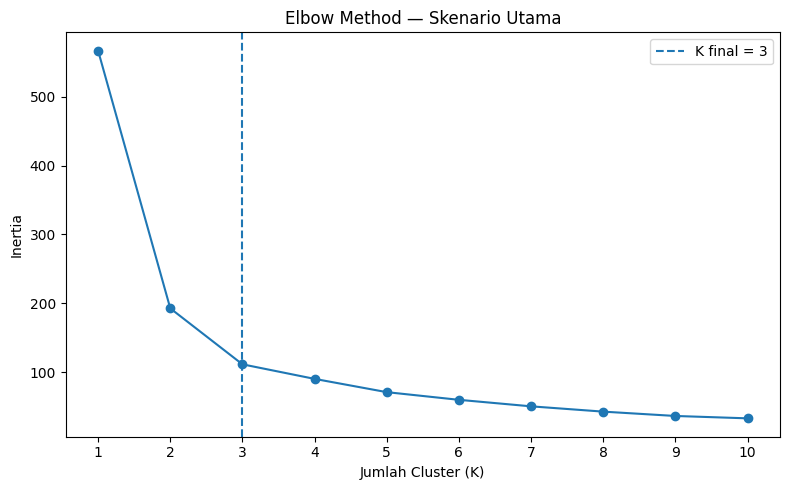

In [ ]:

# ============================================================
# 17. VISUALISASI ELBOW
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(
    evaluation_main["k"],
    evaluation_main["inertia"],
    marker="o",
)
plt.axvline(
    FINAL_K,
    linestyle="--",
    label=f"K final = {FINAL_K}",
)
plt.title("Elbow Method — Skenario Utama")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.xticks(
    evaluation_main["k"]
)
plt.legend()
plt.tight_layout()
plt.savefig(
    "04_Elbow_Method.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


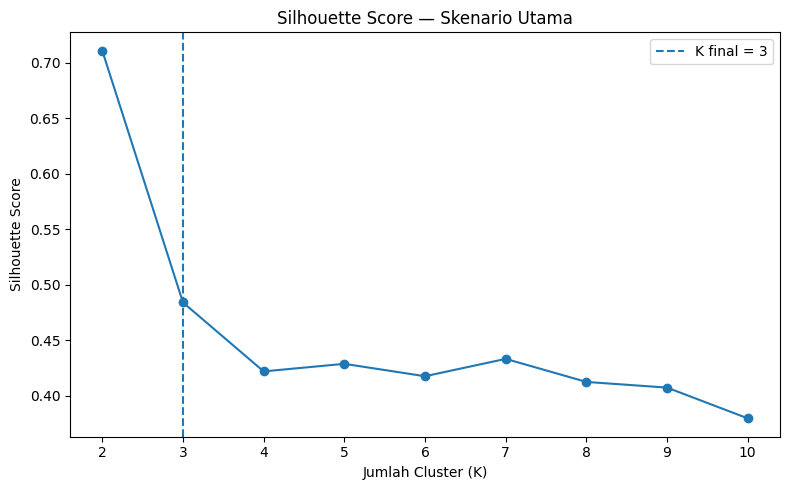

In [ ]:

# ============================================================
# 18. VISUALISASI SILHOUETTE
# ============================================================
silhouette_plot = evaluation_main.dropna(
    subset=["silhouette"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_plot["k"],
    silhouette_plot["silhouette"],
    marker="o",
)
plt.axvline(
    FINAL_K,
    linestyle="--",
    label=f"K final = {FINAL_K}",
)
plt.title("Silhouette Score — Skenario Utama")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.xticks(
    silhouette_plot["k"]
)
plt.legend()
plt.tight_layout()
plt.savefig(
    "04_Silhouette_Score.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


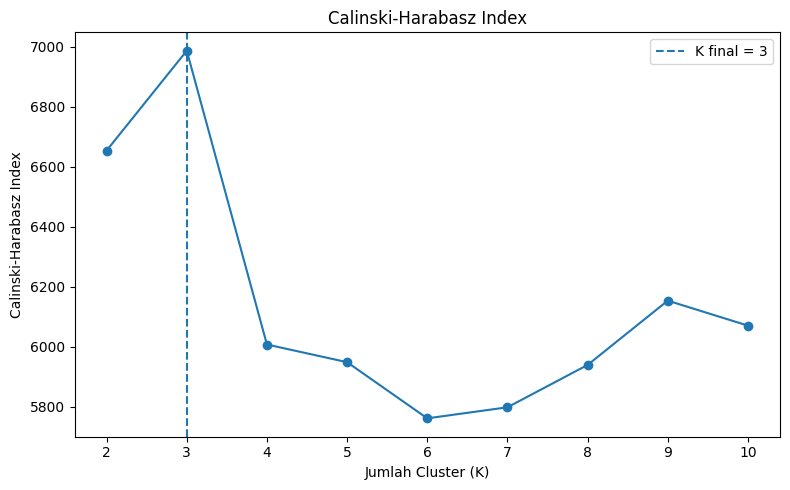

In [ ]:

# ============================================================
# 19. VISUALISASI CALINSKI-HARABASZ
# ============================================================
metric_plot = evaluation_main.dropna(
    subset=["calinski_harabasz"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    metric_plot["k"],
    metric_plot["calinski_harabasz"],
    marker="o",
)
plt.axvline(
    FINAL_K,
    linestyle="--",
    label=f"K final = {FINAL_K}",
)
plt.title("Calinski-Harabasz Index")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Calinski-Harabasz Index")
plt.xticks(
    metric_plot["k"]
)
plt.legend()
plt.tight_layout()
plt.savefig(
    "04_Calinski_Harabasz.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


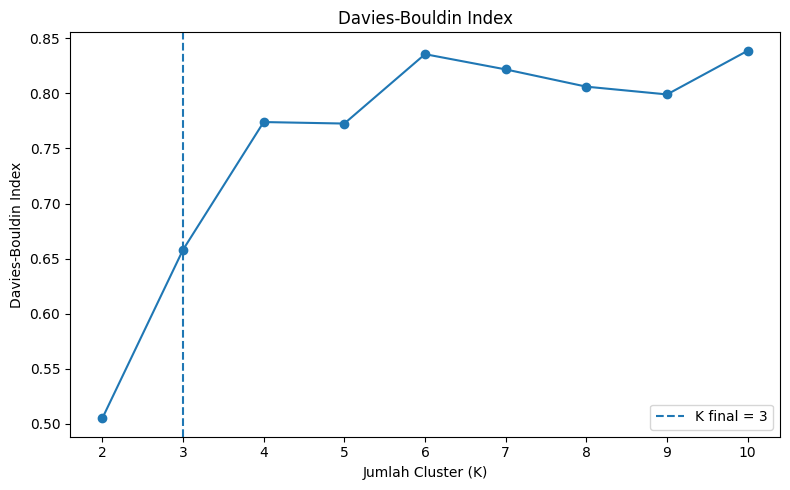

In [ ]:

# ============================================================
# 20. VISUALISASI DAVIES-BOULDIN
# ============================================================
metric_plot = evaluation_main.dropna(
    subset=["davies_bouldin"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    metric_plot["k"],
    metric_plot["davies_bouldin"],
    marker="o",
)
plt.axvline(
    FINAL_K,
    linestyle="--",
    label=f"K final = {FINAL_K}",
)
plt.title("Davies-Bouldin Index")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Davies-Bouldin Index")
plt.xticks(
    metric_plot["k"]
)
plt.legend()
plt.tight_layout()
plt.savefig(
    "04_Davies_Bouldin.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


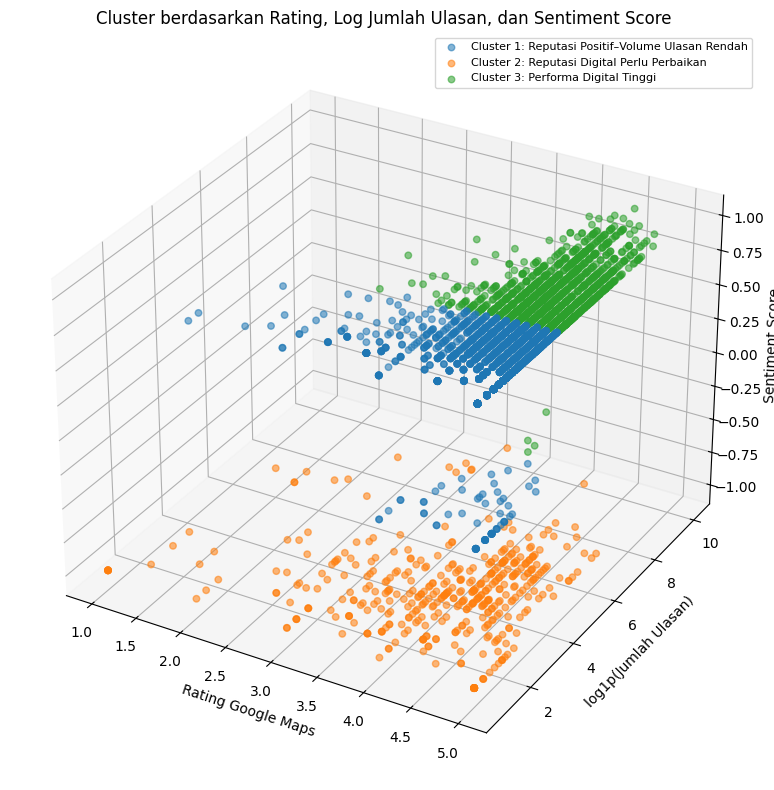

In [ ]:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# 21. SCATTER RATING VS LOG JUMLAH ULASAN (3D)
# ============================================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster_id in sorted(
    df["cluster_id"].unique()
):
    subset = df[
        df["cluster_id"] == cluster_id
    ]

    label = subset[
        "cluster_name"
    ].iloc[0]

    ax.scatter(
        subset["totalScore"],
        subset["log_reviewsCount"],
        subset["sentiment_score"],
        alpha=0.55,
        s=22,
        label=f"Cluster {cluster_id}: {label}",
    )

ax.set_title(
    "Cluster berdasarkan Rating, Log Jumlah Ulasan, dan Sentiment Score"
)
ax.set_xlabel("Rating Google Maps")
ax.set_ylabel("log1p(Jumlah Ulasan)")
ax.set_zlabel("Sentiment Score") # Add z-axis label
ax.legend(
    fontsize=8,
    loc="best",
)
plt.tight_layout()
plt.savefig(
    "04_Scatter_Rating_LogReviews_Sentiment_3D.png", # New filename for 3D plot
    dpi=200,
    bbox_inches="tight",
)
plt.show()


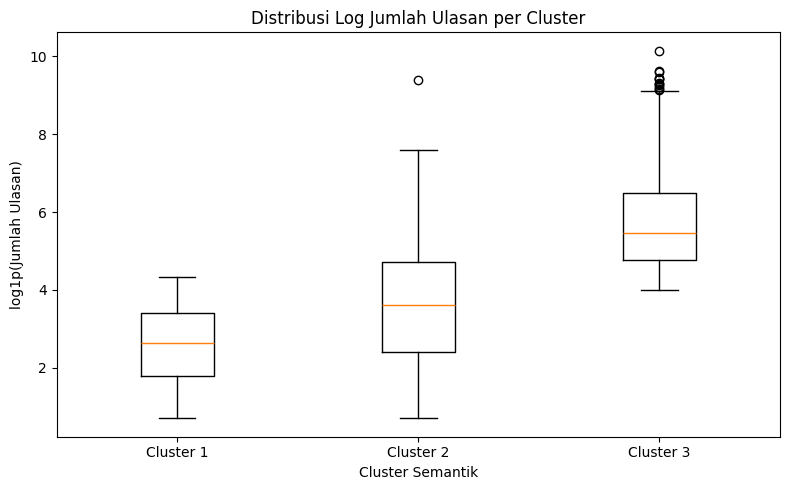

In [ ]:

# ============================================================
# 22. BOXPLOT JUMLAH ULASAN PER CLUSTER
# ============================================================
boxplot_data = [
    df.loc[
        df["cluster_id"] == cluster_id,
        "log_reviewsCount",
    ].to_numpy()
    for cluster_id in [1, 2, 3]
]

plt.figure(figsize=(8, 5))
plt.boxplot(
    boxplot_data,
    tick_labels=[
        "Cluster 1",
        "Cluster 2",
        "Cluster 3",
    ],
)
plt.title(
    "Distribusi Log Jumlah Ulasan per Cluster"
)
plt.xlabel("Cluster Semantik")
plt.ylabel("log1p(Jumlah Ulasan)")
plt.tight_layout()
plt.savefig(
    "04_Boxplot_LogReviews.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


In [ ]:

# ============================================================
# 23. MENYIAPKAN OUTPUT
# ============================================================
result_columns = [
    "entity_key",
    "title",
    "totalScore",
    "reviewsCount",
    "street",
    "city",
    "categoryName",
    "text",
    "jumlah_teks_untuk_sentimen",
    "sentiment_score",
    "sentimen_confidence",
    "log_reviewsCount",
    "scaled_totalScore",
    "scaled_log_reviewsCount",
    "scaled_sentiment_score",
    "cluster_raw",
    "cluster_id",
    "cluster_name",
    "cluster_short_name",
    "nlp_review_flag",
    "nlp_review_reason",
]

df_result = df[
    result_columns
].copy()

modeling_columns = [
    "entity_key",
    "title",
    "totalScore",
    "reviewsCount",
    "street",
    "city",
    "categoryName",
    "jumlah_teks_untuk_sentimen",
    "sentiment_score",
    "sentimen_confidence",
    "log_reviewsCount",
    "cluster_id",
    "cluster_name",
]

df_modeling_ringkas = df_result[
    modeling_columns
].copy()

print("Data hasil cluster:", df_result.shape)
print(
    "Data modeling ringkas:",
    df_modeling_ringkas.shape,
)


Data hasil cluster: (3438, 21)
Data modeling ringkas: (3438, 13)


In [ ]:

# ============================================================
# 24. REKONSILIASI DATA
# ============================================================
reconciliation = pd.DataFrame([
    {
        "tahap": "Input hasil NLP",
        "jumlah_sebelum": len(df),
        "jumlah_dihapus": 0,
        "jumlah_sesudah": len(df),
        "keterangan": (
            "Seluruh baris mempunyai fitur numerik valid."
        ),
    },
    {
        "tahap": "Feature engineering dan scaling",
        "jumlah_sebelum": len(df),
        "jumlah_dihapus": 0,
        "jumlah_sesudah": len(df),
        "keterangan": (
            "Membentuk log_reviewsCount dan Min-Max Scaling."
        ),
    },
    {
        "tahap": "K-Means final K=3",
        "jumlah_sebelum": len(df),
        "jumlah_dihapus": 0,
        "jumlah_sesudah": len(df_result),
        "keterangan": (
            "Tidak ada baris yang dihapus pada modeling."
        ),
    },
])

display(reconciliation)


,tahap,jumlah_sebelum,jumlah_dihapus,jumlah_sesudah,keterangan
0,Input hasil NLP,3438,0,3438,Seluruh baris mempunyai fitur numerik valid.
1,Feature engineering dan scaling,3438,0,3438,Membentuk log_reviewsCount dan Min-Max Scaling.
2,K-Means final K=3,3438,0,3438,Tidak ada baris yang dihapus pada modeling.


In [ ]:
# ============================================================
# 25. EKSPOR HASIL
# ============================================================
df_result.to_csv(
    OUTPUT_CLUSTER_CSV,
    index=False,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
)

df_modeling_ringkas.to_csv(
    OUTPUT_MODELING_CSV,
    index=False,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
)

df_result.to_csv(
    OUTPUT_AUDIT_CSV,
    index=False,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
)

profile_final.to_csv(
    "04_Profil_Cluster.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
)

evaluation_all.to_csv(
    "04_Evaluasi_Semua_K.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
)

final_metrics.to_csv(
    "04_Metrik_Model_Final.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig",
    decimal=",",
)

print("Berhasil membuat:")
print("-", OUTPUT_CLUSTER_CSV)
print("-", OUTPUT_MODELING_CSV)
print("-", OUTPUT_AUDIT_CSV)


Berhasil membuat:
- 04_Hasil_Clustering_Final.csv
- 04_Data_Modeling_Ringkas.csv
- 04_Hasil_Clustering_dan_Audit.xlsx


In [ ]:

# ============================================================
# 26. VALIDASI AKHIR
# ============================================================
assert len(df_result) == EXPECTED_ROWS
assert df_result["entity_key"].is_unique
assert df_result["cluster_id"].isin(
    [1, 2, 3]
).all()
assert df_result["cluster_name"].notna().all()
assert df_result[
    [
        "scaled_totalScore",
        "scaled_log_reviewsCount",
        "scaled_sentiment_score",
    ]
].notna().all().all()

cluster_counts = (
    df_result["cluster_id"]
    .value_counts()
    .sort_index()
)

assert cluster_counts.sum() == EXPECTED_ROWS
assert len(cluster_counts) == 3

print("SEMUA VALIDASI MODELING LULUS.")
print("Jumlah hasil clustering:", len(df_result))
display(cluster_counts.rename("jumlah").to_frame())


SEMUA VALIDASI MODELING LULUS.
Jumlah hasil clustering: 3438


,jumlah
cluster_id,
1,1748
2,435
3,1255


In [ ]:
# ============================================================
# 27. DOWNLOAD
# ============================================================
download_files = [
    OUTPUT_CLUSTER_CSV,
    OUTPUT_MODELING_CSV,
    OUTPUT_AUDIT_CSV,
    "04_Elbow_Method.png",
    "04_Silhouette_Score.png",
    "04_Calinski_Harabasz.png",
    "04_Davies_Bouldin.png",
    "04_Scatter_Rating_LogReviews.png",
    "04_Boxplot_LogReviews.png",
]

if RUNNING_IN_COLAB:
    for file_name in download_files:
        if os.path.exists(file_name):
            files.download(file_name)
else:
    print("File tersimpan pada folder kerja.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretasi yang boleh digunakan

### Cluster 1 — Reputasi Positif–Volume Ulasan Rendah

Rating dan hasil sentiment analysis cenderung positif, tetapi volume ulasan Google Maps relatif lebih rendah dibandingkan cluster lain dalam dataset. Kondisi ini hanya menggambarkan jejak ulasan digital yang lebih terbatas. Hasil tersebut tidak membuktikan bahwa usaha sepi, memiliki sedikit pelanggan, kurang populer secara offline, atau mempunyai penjualan rendah.

### Cluster 2 — Reputasi Digital Perlu Perbaikan

Hasil sentimen teks relatif lebih rendah atau negatif. Interpretasi perlu dilakukan secara hati-hati karena bahasa daerah, slang, ejaan tidak baku, jumlah teks terbatas, dan konteks lokal dapat menyebabkan kesalahan sentiment analysis. Cluster ini tidak boleh langsung disebut sebagai kelompok usaha yang buruk.

### Cluster 3 — Performa Digital Tinggi

Rating baik, hasil sentimen cenderung positif, dan volume ulasan Google Maps relatif tinggi. Istilah ini menggambarkan performa digital pada data Google Maps, bukan omzet, laba, pangsa pasar, jumlah pelanggan, atau kepemimpinan pasar.

## Batasan penting

`reviewsCount` merupakan indikator volume ulasan Google Maps, bukan jumlah pelanggan atau tingkat keramaian aktual. Suatu usaha dapat ramai secara offline tetapi mempunyai sedikit ulasan karena karakteristik kategori, perilaku pelanggan, pembelian rutin, kebutuhan mendesak, atau rendahnya kecenderungan pelanggan memberi ulasan.

Hasil sentiment analysis juga tidak dianggap sebagai kebenaran absolut. Label merupakan keluaran model bahasa dan dapat salah pada konteks lokal. Temuan cluster harus dibaca bersama rating, jumlah ulasan, jumlah teks, dan hasil pemeriksaan NLP konservatif.